# Resultados y Robustez

Metricas, visualizaciones y test de Monte Carlo del algoritmo (vectorizado, sin bucles for).


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import time

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

In [2]:
# --- Cargar resultados de la estrategia desde pickle ---
from pathlib import Path

history_pickle_path = Path('resultadosEjecucion1') / 'history_df.pkl'
if not history_pickle_path.exists():
    raise ValueError("No se encontro 'resultadosEjecucion1/history_df.pkl'. Ejecuta primero ejecucionCostes.ipynb para generarlo.")

hist = pd.read_pickle(history_pickle_path).copy()
hist['date'] = pd.to_datetime(hist['date'])
hist = hist.sort_values('date').set_index('date')

strategy_ret = hist['portfolio_value'].pct_change().dropna()
strategy_cum = (1 + strategy_ret).cumprod()

# Coste mensual usado en Monte Carlo: estimado desde txn_cost guardado en history_df.pkl
monthly_cost_rate = 0.0046
if 'txn_cost' in hist.columns:
    prev_port = hist['portfolio_value'].shift(1)
    fee_series = pd.to_numeric(hist['txn_cost'], errors='coerce').fillna(0.0)
    cost_rate = (fee_series / prev_port).replace([np.inf, -np.inf], np.nan).dropna()
    cost_rate = cost_rate[cost_rate > 0]
    if len(cost_rate) > 0:
        monthly_cost_rate = float(cost_rate.median())

print('Origen historial:', history_pickle_path.as_posix())
print('Rango estrategia:', strategy_ret.index.min().date(), '->', strategy_ret.index.max().date(), 'meses:', len(strategy_ret))
print('Coste mensual usado en Monte Carlo:', f'{monthly_cost_rate:.4%}')

strategy_ret.head()



Origen historial: resultadosEjecucion1/history_df.pkl
Rango estrategia: 2015-02-28 -> 2026-01-31 meses: 132
Coste mensual usado en Monte Carlo: 0.3819%


date
2015-02-28    0.037197
2015-03-31    0.017430
2015-04-30   -0.039575
2015-05-31    0.033998
2015-06-30    0.001045
Name: portfolio_value, dtype: float64

In [3]:
# Benchmark SPY - Usamos datos mensuales para alinear con rebalanceos mensuales de la estrategia
bench_start = (strategy_ret.index.min() - pd.offsets.MonthBegin(1)).strftime('%Y-%m-%d')
bench_end = (strategy_ret.index.max() + pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')

spy = yf.download('SPY', start=bench_start, end=bench_end, auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)
spy = spy.reset_index().rename(columns={'Date': 'date'})
spy['date'] = pd.to_datetime(spy['date'])
spy = spy.set_index('date')
spy_m = spy.resample('ME').last()
spy_ret = spy_m['Close'].pct_change().dropna()

# Alinear fechas
common_idx = strategy_ret.index.intersection(spy_ret.index)
strategy_ret = strategy_ret.loc[common_idx]
spy_ret = spy_ret.loc[common_idx]
strategy_cum = (1 + strategy_ret).cumprod()
spy_cum = (1 + spy_ret).cumprod()

print('Fechas comunes:', common_idx.min().date(), '->', common_idx.max().date(), 'meses:', len(common_idx))


Fechas comunes: 2015-03-31 -> 2026-01-31 meses: 131


In [ ]:
# Metricas 
def cagr(returns, periods_per_year=12):
    """
    Calcula CAGR (tasa anual compuesta) a partir de una serie de retornos periodicos.

    Parametros:
    - returns (pd.Series): retornos periodicos de la estrategia o benchmark.
    - periods_per_year (int): numero de periodos por ano (12 para mensual).

    Devuelve:
    - float: CAGR de la serie; NaN si la serie esta vacia.
    """
    n = len(returns)
    if n == 0:
        return np.nan
    total = (1 + returns).prod()
    years = n / periods_per_year
    return total ** (1 / years) - 1


def vol(returns, periods_per_year=12):
    """
    Calcula volatilidad anualizada de una serie de retornos.

    Parametros:
    - returns (pd.Series): retornos periodicos.
    - periods_per_year (int): numero de periodos por ano.

    Devuelve:
    - float: volatilidad anualizada.
    """
    return returns.std() * np.sqrt(periods_per_year)


def sharpe(returns, rf=0.0, periods_per_year=12):
    """
    Calcula ratio de Sharpe anualizado.

    Parametros:
    - returns (pd.Series): retornos periodicos.
    - rf (float): tasa libre de riesgo anual.
    - periods_per_year (int): numero de periodos por ano.

    Devuelve:
    - float: ratio de Sharpe; NaN si la volatilidad es cero.
    """
    excess = returns - rf / periods_per_year
    v = excess.std()
    return np.nan if v == 0 else (excess.mean() / v) * np.sqrt(periods_per_year)


def sortino(returns, rf=0.0, periods_per_year=12):
    """
    Calcula ratio de Sortino anualizado usando solo volatilidad a la baja.

    Parametros:
    - returns (pd.Series): retornos periodicos.
    - rf (float): tasa libre de riesgo anual.
    - periods_per_year (int): numero de periodos por ano.

    Devuelve:
    - float: ratio de Sortino; NaN si no hay desviacion negativa.
    """
    excess = returns - rf / periods_per_year
    downside = excess[excess < 0].std()
    return np.nan if downside == 0 or np.isnan(downside) else (excess.mean() / downside) * np.sqrt(periods_per_year)


def max_drawdown(cum_returns):
    """
    Calcula maximo drawdown de una curva de capital acumulada.

    Parametros:
    - cum_returns (pd.Series): curva acumulada (base 1.0 o equivalente).

    Devuelve:
    - float: max drawdown (valor negativo o cero).
    """
    peak = cum_returns.cummax()
    dd = cum_returns / peak - 1
    return dd.min()

metrics = pd.DataFrame({
    'CAGR': [cagr(strategy_ret), cagr(spy_ret)],
    'Volatilidad': [vol(strategy_ret), vol(spy_ret)],
    'Sharpe': [sharpe(strategy_ret), sharpe(spy_ret)],
    'Sortino': [sortino(strategy_ret), sortino(spy_ret)],
    'Max Drawdown': [max_drawdown(strategy_cum), max_drawdown(spy_cum)],
    'Retorno acumulado': [strategy_cum.iloc[-1] - 1, spy_cum.iloc[-1] - 1],
    'Retorno mensual medio': [strategy_ret.mean(), spy_ret.mean()]
}, index=['Estrategia', 'SPY'])

metrics



,CAGR,Volatilidad,Sharpe,Sortino,Max Drawdown,Beta,Alpha
Estrategia,0.065744,0.109268,0.637851,1.066133,-0.122872,0.402204,0.014321
SPY,0.134245,0.148993,0.924064,1.348805,-0.239272,1.000000,0.000000


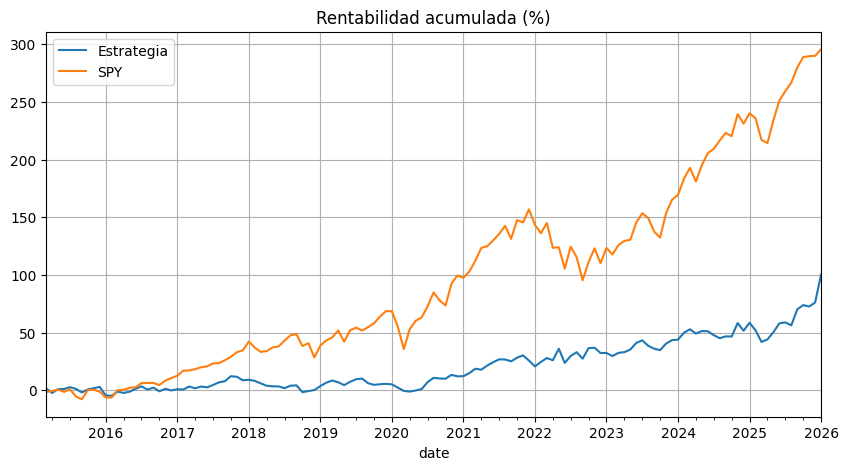

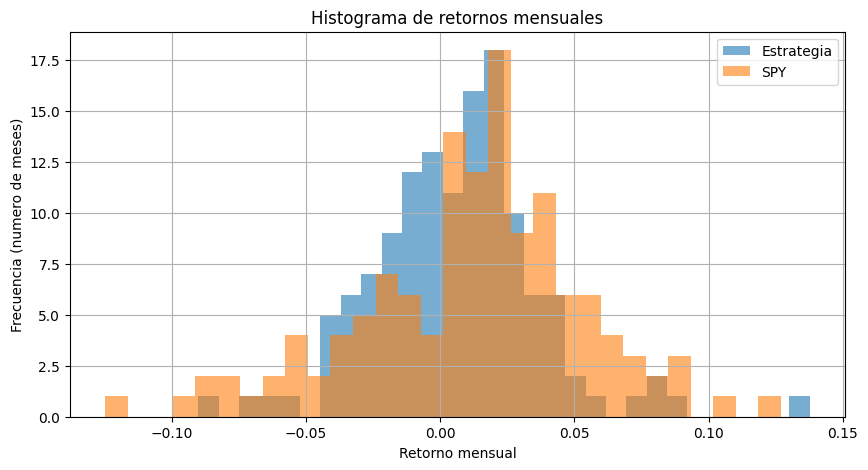

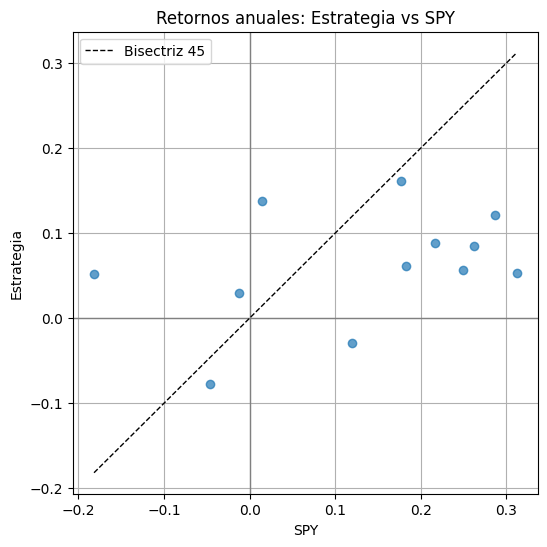

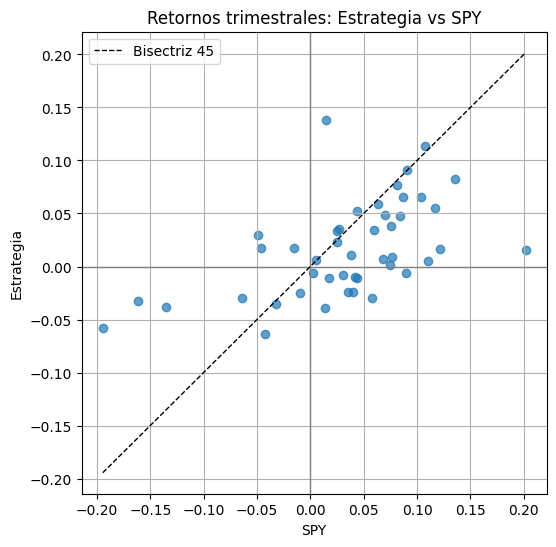

In [15]:
# Visualizaciones 
plt.figure(figsize=(10, 5))
(strategy_cum - 1).mul(100).plot(label='Estrategia')
(spy_cum - 1).mul(100).plot(label='SPY')
plt.title('Rentabilidad acumulada (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(strategy_ret, bins=30, alpha=0.6, label='Estrategia')
plt.hist(spy_ret, bins=30, alpha=0.6, label='SPY')
plt.title('Histograma de retornos mensuales')
plt.xlabel('Retorno mensual')
plt.ylabel('Frecuencia (numero de meses)')
plt.legend()
plt.grid(True)
plt.show()

strategy_year = (1 + strategy_ret).resample('YE').prod() - 1
spy_year = (1 + spy_ret).resample('YE').prod() - 1

plt.figure(figsize=(6, 6))
plt.scatter(spy_year, strategy_year, alpha=0.7)
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
min_val = min(spy_year.min(), strategy_year.min())
max_val = max(spy_year.max(), strategy_year.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1, label='Bisectriz 45')
plt.title('Retornos anuales: Estrategia vs SPY')
plt.xlabel('SPY')
plt.ylabel('Estrategia')
plt.legend()
plt.grid(True)
plt.show()

strategy_quarter = (1 + strategy_ret).resample('QE').prod() - 1
spy_quarter = (1 + spy_ret).resample('QE').prod() - 1

plt.figure(figsize=(6, 6))
plt.scatter(spy_quarter, strategy_quarter, alpha=0.7)
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
min_val = min(spy_quarter.min(), strategy_quarter.min())
max_val = max(spy_quarter.max(), strategy_quarter.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1, label='Bisectriz 45')
plt.title('Retornos trimestrales: Estrategia vs SPY')
plt.xlabel('SPY')
plt.ylabel('Estrategia')
plt.legend()
plt.grid(True)
plt.show()




## Test de Monte Carlo (>= 25M monos, vectorizado)

- Coste de rebalanceo: 0.23% x2 mensual (0.46%) aplicado al 100% del capital.
- Sin minimo de 23 USD por orden.


In [7]:
# Matriz de retornos log mensuales del universo completo (por symbol)
df = pd.read_pickle('sp500_history_filtered.pkl')[['date', 'symbol', 'close']].copy()
df['date'] = pd.to_datetime(df['date'])
df['close'] = pd.to_numeric(df['close'], errors='coerce')
df = df.dropna(subset=['date', 'symbol', 'close'])

monthly = (
    df.set_index('date')
      .groupby('symbol')
      .resample('ME')
      .last()
      .reset_index()
)
monthly['log_ret'] = np.log(monthly['close'] / monthly.groupby('symbol')['close'].shift(1))
monthly = monthly.dropna(subset=['log_ret'])

# Usar el mismo rango temporal de la estrategia ya alineada con SPY
monthly = monthly[monthly['date'].isin(strategy_ret.index)].copy()

ret_matrix_all = (
    monthly.pivot(index='date', columns='symbol', values='log_ret')
          .sort_index()
)

# Symbols con historial completo durante todo el periodo
ret_matrix = ret_matrix_all.dropna(axis=1, how='any').copy()

if ret_matrix.shape[1] < 20:
    raise ValueError(f'No hay suficientes symbols completos para simular monos de 20 activos: {ret_matrix.shape[1]}')

print('Ret matrix (meses, symbols):', ret_matrix.shape)
ret_matrix.head()


Ret matrix (meses, symbols): (131, 597)


symbol,A,AAL,AAP,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIV,AIZ,AJG,AKAM,ALB,ALGN,ALK,...,WFC,WFRD,WHR,WM,WMB,WMT,WOR,WRB,WSM,WST,WTW,WU,WY,WYNN,XEL,XOM,XRAY,XRX,XYL,YELLQ,YUM,ZBH,ZBRA,ZION,ZTS
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-03-31,-0.013300,0.097017,-0.034007,-0.031874,-0.032933,-0.022199,0.040416,0.039849,-0.067459,0.073424,-0.010076,-0.030913,-0.091209,0.005099,-0.023369,-0.009295,0.027881,-0.007577,0.043621,0.002282,0.002785,0.021843,-0.062779,-0.064178,0.038979,...,-0.007144,-0.031215,-0.047786,0.002416,0.043354,-0.014231,-0.007384,0.014094,-0.009241,0.095609,0.016066,0.071942,-0.057443,-0.124013,-0.004079,-0.040803,-0.039413,-0.054942,-0.019231,-0.092979,-0.029909,-0.022282,-0.003686,0.009863,0.004330
2015-04-30,-0.004342,-0.086963,-0.045722,0.005770,0.107692,0.007044,-0.015048,-0.000524,0.028269,-0.018584,0.030746,-0.012928,-0.031353,-0.030313,0.010962,0.030654,-0.015270,0.027009,-0.042295,0.000814,0.022839,0.037774,0.122064,0.089827,-0.032558,...,0.012786,0.167992,-0.140356,-0.090656,0.011790,-0.052414,0.015660,-0.030555,-0.076130,-0.120296,0.009297,-0.025798,-0.050738,-0.125168,-0.026195,0.027501,0.002159,-0.110997,0.055539,-0.140876,0.093236,-0.067584,0.014935,0.048261,-0.039443
2015-05-31,-0.004360,-0.130680,0.069030,0.044341,0.029412,0.045893,0.051549,0.035936,0.039064,0.100370,0.083373,0.011409,-0.048306,-0.017495,-0.000725,0.033648,-0.006949,0.040388,0.013190,0.073514,0.012879,0.033192,0.007509,0.030627,0.011977,...,0.022240,-0.051474,0.052924,0.002420,-0.001760,-0.043351,0.006637,0.000204,0.066805,0.016012,-0.024353,0.079132,0.032780,-0.093706,0.004120,-0.016914,0.020091,-0.006981,-0.008416,-0.170849,0.047149,0.039925,0.174545,0.021110,0.113723
2015-06-30,-0.062962,-0.059187,0.039229,-0.037978,0.008970,0.009828,0.046933,0.007675,0.023986,-0.057150,-0.091684,-0.057826,-0.078236,-0.054741,-0.060791,-0.025318,-0.000321,0.055419,-0.026718,0.017313,-0.016342,-0.088359,-0.079881,0.033072,-0.003254,...,0.004991,-0.118959,-0.062713,-0.060978,0.128410,-0.046014,0.106053,0.060467,0.045508,0.070248,-0.005219,-0.069554,-0.024112,-0.020266,-0.046590,-0.023754,-0.007998,-0.064368,0.013580,-0.013012,-0.000333,-0.043532,0.012778,0.094271,-0.031639
2015-07-31,0.059618,0.004123,0.089535,-0.033441,0.048508,0.037095,0.063642,0.063356,0.012025,-0.095653,-0.016730,-0.005750,0.010034,0.086392,0.065753,-0.027482,0.029309,0.036529,0.056587,0.107448,0.002745,0.094112,-0.019549,-0.000159,0.161859,...,0.028571,-0.138784,0.026685,0.098150,-0.089438,0.014695,-0.105139,0.070443,0.032888,0.032158,-0.008780,-0.004437,-0.026051,0.045179,0.074530,-0.049145,0.098919,0.035091,-0.070979,0.396695,-0.021625,-0.048392,-0.031281,-0.017323,0.015638


In [8]:
# Estimacion de memoria para Monte Carlo por bloques (20 activos por mono)
def estimar_memoria_chunk(n_monos, n_pick=20, chunk_size=500_000):
    """
    Estima consumo de memoria para la simulacion Monte Carlo por bloques.

    Parametros:
    - n_monos (int): numero total de carteras aleatorias a simular.
    - n_pick (int): numero de activos por mono.
    - chunk_size (int): tamano del bloque de simulacion.

    Devuelve:
    - dict: estimaciones en GB de componentes clave y total aproximado.
    """
    BYTES_FLOAT = 4
    BYTES_INT = 4
    GB = 1024**3

    mem_total_log = (n_monos * BYTES_FLOAT) / GB
    mem_idx_chunk = (chunk_size * n_pick * BYTES_INT) / GB
    mem_vals_chunk = (chunk_size * n_pick * BYTES_FLOAT) / GB
    mem_chunk_out = (chunk_size * BYTES_FLOAT) / GB

    overhead_factor = 1.3
    mem_working = (mem_idx_chunk + mem_vals_chunk + mem_chunk_out) * overhead_factor
    mem_total = mem_total_log + mem_working

    return {
        'n_monos': n_monos,
        'n_pick': n_pick,
        'chunk_size': chunk_size,
        'all_total_log_GB': mem_total_log,
        'working_chunk_GB': mem_working,
        'total_estimado_GB': mem_total,
    }

mem_est = estimar_memoria_chunk(n_monos=25_000_000, n_pick=20, chunk_size=500_000)
pd.DataFrame([mem_est]).T



Memoria total_log (GB): 0.09
Memoria idx chunk (GB): 0.04
Memoria vals chunk (GB): 0.04
Memoria salida chunk (GB): 0.00
Pico estimado (GB): 0.17


CAGR estrategia: 0.06574426565210123
Porcentaje de monos superados por estrategia: 0.87827068
Tiempo de ejecucion (seg): 4.305162600001495

RESULTADOS DE 25,000,000 MONOS
 Percentil Retorno acumulado
        10             1.93%
        20            19.82%
        30            32.09%
        40            42.42%
        50            52.09%
        60            61.94%
        70            72.79%
        80            86.03%
        90           105.69%
       100           485.20%
Ubicacion de Benchmarks:
SPY (S&P 500) se situa en el percentil: 100.00%
Monos representativos (muestra):
 Percentil  Mono_ID Retorno acumulado
        10   169852             2.06%
        20    59959            19.98%
        30   152295            32.20%
        40   133279            42.51%
        50    54680            52.11%
        60   171511            61.88%
        70   187365            72.87%
        80   196358            86.06%
        90     4808           105.56%
       100    84929     

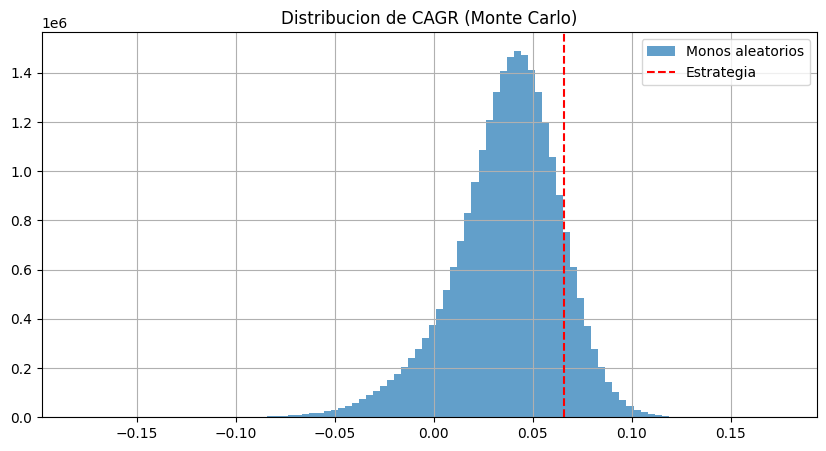

In [12]:
# Monte Carlo: 25M monos, 20 activos por mono, peso 5% cada uno (por bloques)
start = time.perf_counter()

N_AGENTS = int(globals().get('N_AGENTS', 25_000_000))
N_PICK = 20
WEIGHT = 1.0 / N_PICK
CHUNK_SIZE = int(globals().get('CHUNK_SIZE', 500_000))
N_REP = int(globals().get('N_REP', 200_000))  # muestra para monos representativos

months = ret_matrix.shape[0]
n_assets = ret_matrix.shape[1]
if n_assets < N_PICK:
    raise ValueError(f'No hay suficientes assets para N_PICK={N_PICK}: {n_assets}')

sum_log = ret_matrix.sum(axis=0).values.astype(np.float32)
rng = np.random.default_rng(42)
cost_log = np.log(1 - monthly_cost_rate)

# 1) Simulacion grande para distribucion/percentiles
all_total_log = np.empty(N_AGENTS, dtype=np.float32)

for i0 in range(0, N_AGENTS, CHUNK_SIZE):
    i1 = min(i0 + CHUNK_SIZE, N_AGENTS)
    c = i1 - i0

    idx_chunk = rng.integers(0, n_assets, size=(c, N_PICK), dtype=np.int32)
    chunk_total = sum_log[idx_chunk].sum(axis=1, dtype=np.float64) * WEIGHT
    all_total_log[i0:i1] = chunk_total.astype(np.float32)

all_total_log = all_total_log + months * cost_log
final_returns = np.expm1(all_total_log)

years = months / 12
cagr_agents = np.exp(all_total_log / years) - 1
strategy_cagr = cagr(strategy_ret)
pct_beaten = (cagr_agents < strategy_cagr).mean()

percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
perc_values = np.percentile(final_returns, percentiles)

spy_final_ret = (1 + spy_ret).prod() - 1
perc_spy = (final_returns < spy_final_ret).mean() * 100

elapsed = time.perf_counter() - start
print('CAGR estrategia:', strategy_cagr)
print('Porcentaje de monos superados por estrategia:', pct_beaten)
print('Tiempo de ejecucion (seg):', elapsed)

print(f"\nRESULTADOS DE {N_AGENTS:,} MONOS")
tabla_monos = pd.DataFrame({'Percentil': percentiles, 'Retorno acumulado': perc_values})
tabla_monos['Retorno acumulado'] = tabla_monos['Retorno acumulado'].map(lambda x: f'{x:.2%}')
print(tabla_monos.to_string(index=False))

print('Ubicacion de Benchmarks:')
print(f'SPY (S&P 500) se situa en el percentil: {perc_spy:.2f}%')

# 2) Muestra separada para seleccionar monos representativos (deciles)
rep_idx = rng.integers(0, n_assets, size=(N_REP, N_PICK), dtype=np.int32)
rep_total_log = sum_log[rep_idx].sum(axis=1, dtype=np.float64) * WEIGHT
rep_total_log = rep_total_log + months * cost_log
rep_final_returns = np.expm1(rep_total_log)

sorted_rep = np.argsort(rep_final_returns)
positions = (np.array(percentiles) / 100 * (N_REP - 1)).astype(int)
representative_monkey_ids = sorted_rep[positions]

tabla_rep = pd.DataFrame({
    'Percentil': percentiles,
    'Mono_ID': representative_monkey_ids,
    'Retorno acumulado': rep_final_returns[representative_monkey_ids],
})
tabla_rep['Retorno acumulado'] = tabla_rep['Retorno acumulado'].map(lambda x: f'{x:.2%}')
print('Monos representativos (muestra):')
print(tabla_rep.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.hist(cagr_agents, bins=100, alpha=0.7, label='Monos aleatorios')
plt.axvline(strategy_cagr, color='red', linestyle='--', label='Estrategia')
plt.title('Distribucion de CAGR (Monte Carlo)')
plt.legend()
plt.grid(True)
plt.show()


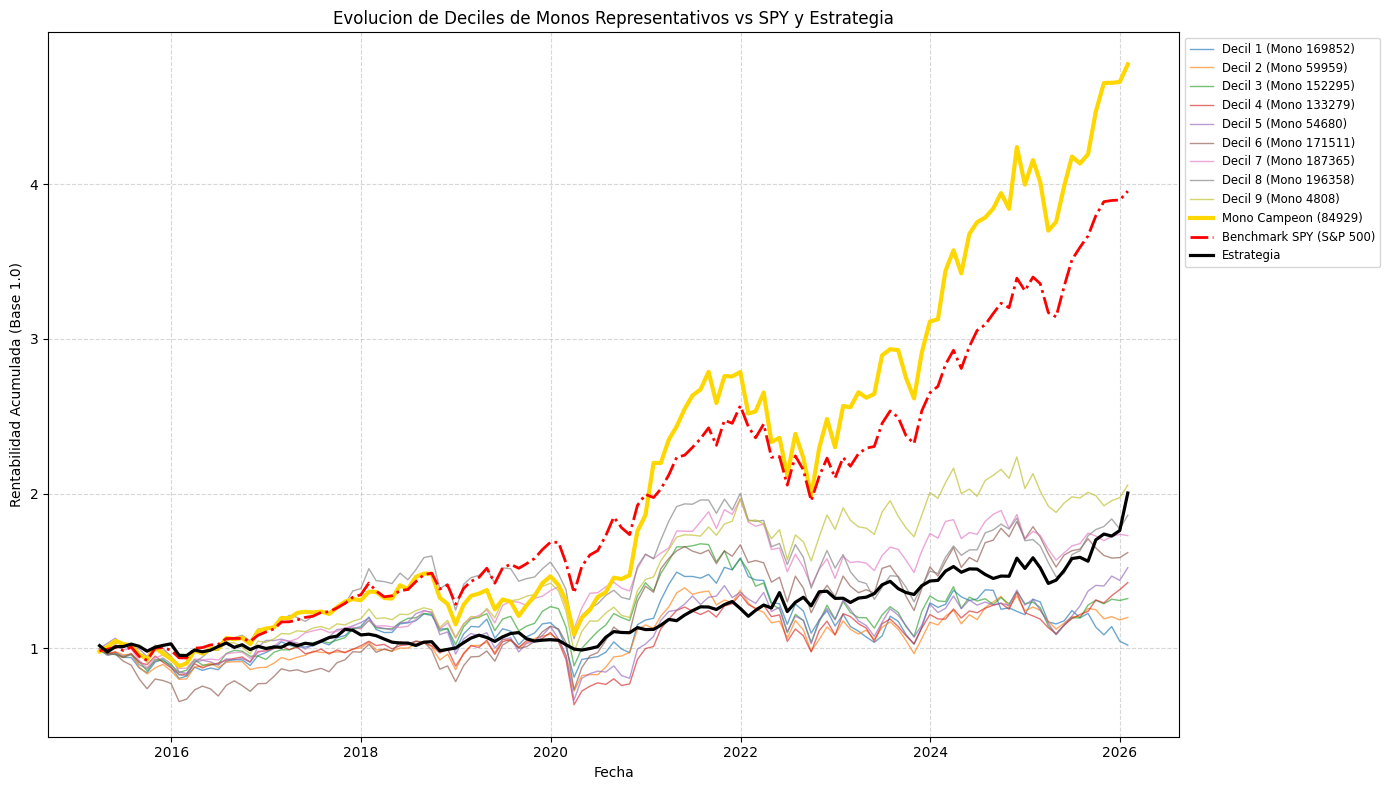

In [11]:
# Evolucion de monos representativos vs SPY y estrategia (base 1.0)
ret_values = ret_matrix.values.astype(np.float32)
plot_dates = ret_matrix.index


def mono_path_from_idx(asset_idx):
    """
    Construye la curva acumulada de un mono representativo dado su indice de activos.

    Parametros:
    - asset_idx (np.ndarray): indices de activos seleccionados para el mono.

    Devuelve:
    - np.ndarray: trayectoria acumulada base 1.0 ajustada por coste mensual.
    """
    monthly_log = ret_values[:, asset_idx].mean(axis=1).astype(np.float64)
    monthly_log = monthly_log + cost_log
    return np.exp(np.cumsum(monthly_log))

plt.figure(figsize=(14, 8))

for i, m_id in enumerate(representative_monkey_ids):
    path = mono_path_from_idx(rep_idx[m_id])
    label = f'Decil {i + 1} (Mono {m_id})' if i < 9 else f'Mono Campeon ({m_id})'
    color = 'gold' if i == 9 else None
    lw = 3 if i == 9 else 1
    alpha = 1.0 if i == 9 else 0.65
    plt.plot(plot_dates, path, label=label, color=color, linewidth=lw, alpha=alpha)

# SPY bien alineado al mismo eje temporal
spy_plot = spy_ret.reindex(plot_dates).dropna()
spy_path = (1 + spy_plot).cumprod()
plt.plot(spy_path.index, spy_path.values, label='Benchmark SPY (S&P 500)', color='red', linewidth=2, linestyle='-.')

# Estrategia bien alineada al mismo eje temporal
strategy_plot = strategy_ret.reindex(plot_dates).dropna()
strategy_path = (1 + strategy_plot).cumprod()
plt.plot(strategy_path.index, strategy_path.values, label='Estrategia', color='black', linewidth=2.3)

plt.title('Evolucion de Deciles de Monos Representativos vs SPY y Estrategia')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad Acumulada (Base 1.0)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## Respuestas a Preguntas de Robustez

### 1) ¿Como nos esta afectando el sesgo de supervivencia?
El sesgo de supervivencia esta mitigado, pero no puede considerarse eliminado al 100%.

- Mitigación aplicada: se usa un universo histórico (no solo constituents actuales), existe la columna `in_sp500`, y en ejecución se fuerza salida si `in_sp500 <= 0` o si hay delisting (venta al ultimo `close` disponible).
- Riesgo residual: depende de la calidad de los datos. Si faltan empresas quebradas/deslistadas en el origen, el sesgo puede seguir parcialmente presente.

### 2) ¿Como hemos garantizado que no haya look-ahead?
Se evita look-ahead en la construccion de senales.

- El momentum se calcula con `shift(1)`, por lo que en el mes `t` solo usa información hasta `t-1`.
- El rebalanceo se ejecuta en el ultimo dia habil del mes (`trade_date`): ventas a `open` y compras a `close`, pero con senales ya conocidas antes de abrir (porque no usan datos del propio mes `t`).
- No se usan precios futuros para construir ranking ni pesos.

### 3) ¿Crees que existe un problema de overfitting?
Hay riesgo moderado, no extremo.

- A favor: reglas simples y económicamente razonables (12M/6M con lag, top-20, pesos fijos), y contraste de robustez con Monte Carlo de monos.
- En contra: sigue siendo un único mercado y un periodo histórico concreto; no hay una validación walk-forward completa ni un barrido formal de sensibilidad de hiperparámetros.

### 4) ¿Hemos realizado un rebalanceo irrealista?
Parcialmente realista, pero con supuestos optimistas.

- Realista: comisión explicita (0.23% con mínimo 23 USD), acciones enteras, banda de rebalanceo, y tratamiento de salida de SP500/delisting.
- Optimista: ejecución exacta a precios `open`/`close`, sin slippage, sin bid-ask spread, sin market impact y sin restricciones operativas.

### 5) Cuanto dinero hemos pagado en comisiones de compraventa?
Con la última ejecución del notebook:

- **Coste total**: **152,255.22 USD**
- Rebalanceos: 133
- Coste medio por rebalanceo: 1,144.78 USD
- Coste mediano por rebalanceo: 1,133.56 USD
- Impacto agregado: reduce el valor final de 670,676.17 USD (sin costes) a 518,420.95 USD (con costes).

